import pandas as pd
from astroquery.gaia import Gaia
import os

print("🚀 Lancement de la requête vers les serveurs de l'ESA...")
print("Cela peut prendre 1 à 2 minutes selon la charge de leurs serveurs.\n")

query = """
SELECT TOP 100000 
    source_id, ra, dec, 
    parallax, parallax_error, 
    pmra, pmra_error, pmdec, pmdec_error,
    phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source 
WHERE parallax IS NOT NULL 
  AND pmra IS NOT NULL 
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
"""

# 2. Exécution et récupération
job = Gaia.launch_job(query)
results = job.get_results()

# 3. Conversion en DataFrame Pandas
df_gaia = results.to_pandas()
print(f"✅ Téléchargement terminé ! Nombre d'étoiles récupérées : {len(df_gaia)}")

# 4. Sauvegarde optimisée en local (format Parquet)
dossier_data = r"data" # Le 'r' est important sous Windows
if not os.path.exists(dossier_data):
    os.makedirs(dossier_data)

chemin_fichier = os.path.join(dossier_data, "gaia_sample_100k.parquet")
df_gaia.to_parquet(chemin_fichier, index=False)
print(f"💾 Données sauvegardées avec succès dans : {chemin_fichier}\n")

# 5. Affichage des 5 premières lignes pour vérifier
display(df_gaia.head())

In [2]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. On recharge les données depuis le fichier parquet (bonne pratique)
df = pd.read_parquet(r"data\gaia_sample_100k.parquet")

# 2. Sélection des caractéristiques (Features)
# On enlève 'source_id' qui n'a aucune valeur physique pour l'IA
features = [
    'ra', 'dec', 'parallax', 'parallax_error', 
    'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 
    'phot_g_mean_mag', 'bp_rp'
]
df_ml = df[features].copy()

# 3. Nettoyage des valeurs manquantes (NaN)
# Les réseaux de neurones plantent s'il y a des "trous" dans les données
df_clean = df_ml.dropna()
print(f"Nombre d'étoiles après suppression des données incomplètes : {len(df_clean)}")

# 4. Standardisation des données (z-score)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clean)

# 5. On remet tout ça dans un beau tableau Pandas pour vérifier
df_scaled = pd.DataFrame(data_scaled, columns=features)

print("✅ Données prêtes pour le Deep Learning !")
display(df_scaled.head())

Nombre d'étoiles après suppression des données incomplètes : 99389
✅ Données prêtes pour le Deep Learning !


,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp
0,-0.279958,-2.431511,-0.262349,0.393681,-0.037688,0.514235,0.029580,0.323979,0.861454,-0.170835
1,-0.235622,-2.395387,-0.574647,-0.699984,0.000323,-0.650376,-0.013498,-0.678888,-0.229193,-1.091119
2,-0.200883,-2.365819,1.004004,-0.876415,-0.169898,-0.850870,-0.865018,-0.845162,-1.575969,-0.154624
3,-0.124734,-2.299362,0.925900,0.882887,0.373012,0.926531,0.561043,0.984024,0.898204,1.114928
4,-0.122304,-2.279621,-0.192368,-0.835809,-0.006840,-0.851576,0.226542,-0.830782,-1.072507,-0.857083


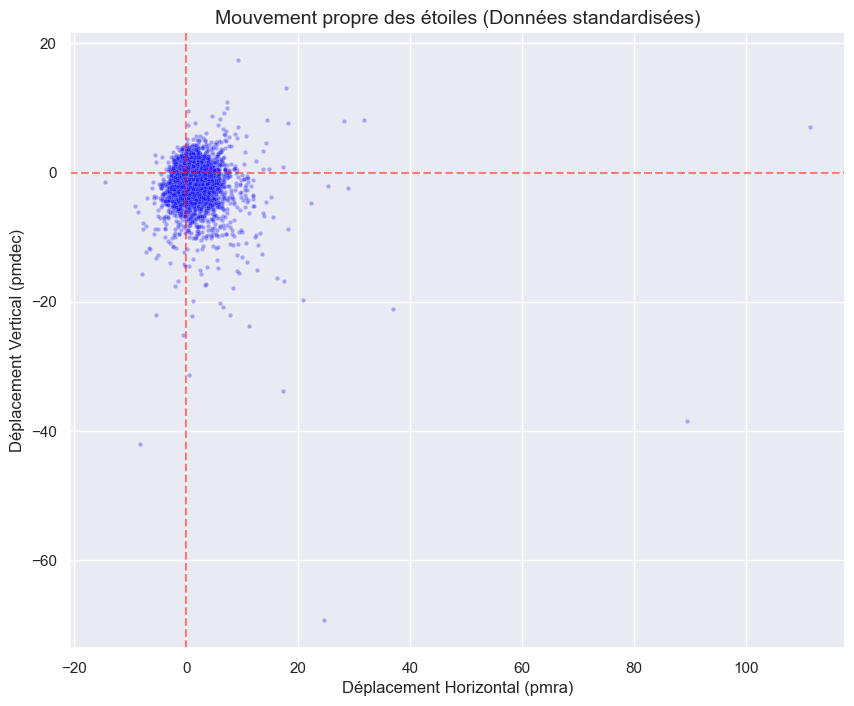

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style du graphique
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 8))

# On trace un nuage de points avec le mouvement propre RA (Axe X) et DEC (Axe Y)
sns.scatterplot(
    x=df_scaled['pmra'], 
    y=df_scaled['pmdec'], 
    alpha=0.3, # Transparence pour voir la densité
    s=10,      # Taille des points
    color="blue"
)

# Lignes de repère au centre (moyenne = 0 grâce à notre standardisation)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.title("Mouvement propre des étoiles (Données standardisées)", fontsize=14)
plt.xlabel("Déplacement Horizontal (pmra)", fontsize=12)
plt.ylabel("Déplacement Vertical (pmdec)", fontsize=12)

plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AnomalyVAE(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=16, latent_dim=4):
        """
        input_dim : Nos 10 colonnes de données (features)
        hidden_dim : Couche intermédiaire pour extraire les motifs
        latent_dim : L'espace compressé (le "cerveau" du VAE)
        """
        super(AnomalyVAE, self).__init__()
        
        # --- 1. ENCODEUR ---
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Sorties de l'encodeur : la moyenne (mu) et le log de la variance (logvar)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # --- 2. DÉCODEUR ---
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)
    
    def reparameterize(self, mu, logvar):
        """ L'astuce probabiliste (Reparameterization trick) """
        std = torch.exp(0.5 * logvar) # Écart-type
        eps = torch.randn_like(std)   # Bruit gaussien aléatoire
        return mu + eps * std
        
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        # Pas de fonction d'activation finale car nos données standardisées 
        # peuvent être négatives ou positives (z-score)
        return self.fc4(h3) 
        
    def forward(self, x):
        # On passe les données dans tout le pipeline
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        
        return x_reconstructed, mu, logvar

# On instancie notre modèle pour vérifier qu'il n'y a pas d'erreur de syntaxe
model = AnomalyVAE()
print("✅ Architecture du VAE créée avec succès !")
print(model)

✅ Architecture du VAE créée avec succès !
AnomalyVAE(
  (fc1): Linear(in_features=10, out_features=16, bias=True)
  (fc_mu): Linear(in_features=16, out_features=4, bias=True)
  (fc_logvar): Linear(in_features=16, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=10, bias=True)
)


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim

# 1. Conversion des données Pandas vers PyTorch Tensors
# On convertit notre tableau standardisé en format compréhensible par la carte graphique
X_tensor = torch.tensor(df_scaled.values, dtype=torch.float32)

# 2. Création du DataLoader
# Pour ne pas surcharger la RAM, on va donner les étoiles à l'IA par paquets de 128
batch_size = 128
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 3. La fonction de Perte (Loss) du VAE
def vae_loss_function(recon_x, x, mu, logvar):
    # A. Erreur de reconstruction (Mean Squared Error)
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    
    # B. Divergence KL
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # On additionne les deux pénalités
    return RECON + KLD

# 4. L'Optimiseur (Adam)
# C'est l'algorithme qui va modifier les paramètres du modèle pour réduire l'erreur
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"✅ Données converties en Tensors : {len(X_tensor)} étoiles.")
print(f"✅ DataLoader prêt (Taille des batchs : {batch_size}).")
print("✅ Fonction de perte (MSE + KLD) et Optimiseur (Adam) initialisés.")

✅ Données converties en Tensors : 99389 étoiles.
✅ DataLoader prêt (Taille des batchs : 128).
✅ Fonction de perte (MSE + KLD) et Optimiseur (Adam) initialisés.


In [6]:
import time

# 1. On envoie le modèle sur la carte graphique (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"🚀 Entraînement lancé sur : {device.type.upper()}\n")

# 2. Paramètres d'entraînement
epochs = 30 # Le modèle va voir l'intégralité des 100 000 étoiles 30 fois
model.train() # On met le modèle en mode "apprentissage"

start_time = time.time()

for epoch in range(epochs):
    train_loss = 0
    
    # On itère sur nos paquets de 128 étoiles
    for batch in dataloader:
        # On récupère les données et on les envoie sur la carte graphique
        data = batch[0].to(device)
        
        # --- LES 5 ÉTAPES SACRÉES DE PYTORCH ---
        optimizer.zero_grad()                                  # 1. Remise à zéro
        recon_batch, mu, logvar = model(data)                  # 2. Prédiction (Forward)
        loss = vae_loss_function(recon_batch, data, mu, logvar)# 3. Calcul de l'erreur
        loss.backward()                                        # 4. Rétropropagation
        optimizer.step()                                       # 5. Mise à jour des poids
        
        train_loss += loss.item()
    
    # On calcule la perte moyenne pour cette "époque" (epoch)
    avg_loss = train_loss / len(dataloader.dataset)
    
    # On affiche l'évolution toutes les 5 époques pour ne pas surcharger l'écran
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Époque [{epoch + 1}/{epochs}] | Perte moyenne (Loss) : {avg_loss:.4f}")

end_time = time.time()
print(f"\n✅ Entraînement terminé en {(end_time - start_time):.2f} secondes !")

🚀 Entraînement lancé sur : CUDA

Époque [1/30] | Perte moyenne (Loss) : 7.9280
Époque [5/30] | Perte moyenne (Loss) : 5.8970
Époque [10/30] | Perte moyenne (Loss) : 5.7644
Époque [15/30] | Perte moyenne (Loss) : 5.7197
Époque [20/30] | Perte moyenne (Loss) : 5.6869
Époque [25/30] | Perte moyenne (Loss) : 5.6617
Époque [30/30] | Perte moyenne (Loss) : 5.6277

✅ Entraînement terminé en 79.15 secondes !


In [7]:
import numpy as np

# 1. On passe le modèle en mode évaluation (figer les poids)
model.eval()

print("🔍 Scan de la galaxie en cours...")

# 2. On coupe le calcul des gradients (on n'apprend plus, on gagne en vitesse)
with torch.no_grad():
    # On envoie toutes les données sur le GPU
    X_tensor_gpu = X_tensor.to(device)
    
    # Le VAE tente de reconstruire toutes les étoiles d'un coup
    recon_X, mu, logvar = model(X_tensor_gpu)
    
    # 3. Calcul de l'erreur (MSE - Mean Squared Error) par étoile
    # On calcule la différence au carré entre la réalité et la prédiction, sur les 10 dimensions
    errors = torch.mean((recon_X - X_tensor_gpu)**2, dim=1)
    
    # On rapatrie les scores sur le processeur (CPU) pour Pandas
    anomaly_scores = errors.cpu().numpy()

# 4. Fusion des résultats avec le tableau d'origine (celui qui a les 'source_id')
df_results = df.loc[df_clean.index].copy()
df_results['anomaly_score'] = anomaly_scores

# 5. On trie le tableau pour mettre les pires anomalies tout en haut !
top_anomalies = df_results.sort_values(by='anomaly_score', ascending=False)

print("✅ Scan terminé ! Voici le TOP 5 des anomalies les plus extrêmes :")
# On n'affiche que les colonnes les plus intéressantes pour simplifier la lecture
display(top_anomalies[['source_id', 'anomaly_score', 'pmra', 'pmdec', 'parallax']].head())

🔍 Scan de la galaxie en cours...
✅ Scan terminé ! Voici le TOP 5 des anomalies les plus extrêmes :


,source_id,anomaly_score,pmra,pmdec,parallax
24566,1227712107314688,68.785904,1400.291765,-515.645438,22.195474
60670,3179036008830848,31.833893,1741.874611,86.494384,116.267814
52664,4267552520347776,24.306768,-122.203027,-563.343417,55.240632
82520,5676885908994304,21.777653,-220.054779,-25.811199,17.575924
19286,769456276704128,17.992813,180.200932,-320.720453,53.084368


F:\Anaconda\envs\gaia_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🌌 Calcul de la projection UMAP en cours...
(L'algorithme réduit les 4 dimensions de l'IA en 2D. Cela prend environ 30 à 60 secondes)


F:\Anaconda\envs\gaia_ai\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


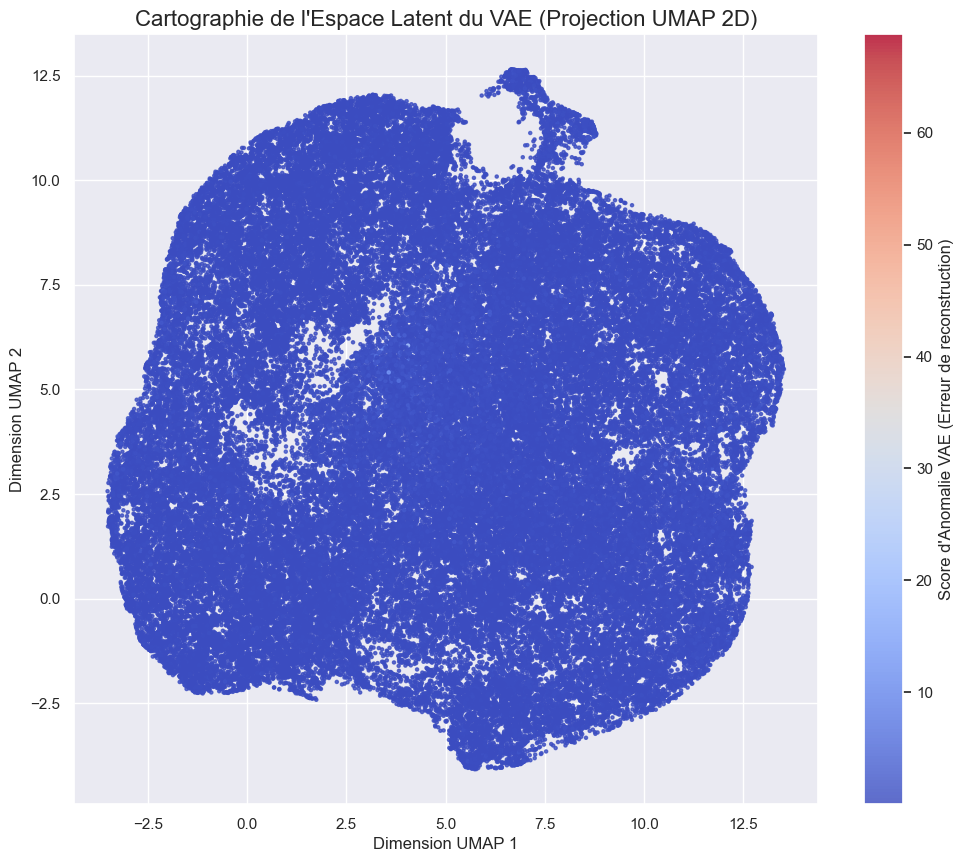

In [8]:
import umap
import matplotlib.pyplot as plt

print("🌌 Calcul de la projection UMAP en cours...")
print("(L'algorithme réduit les 4 dimensions de l'IA en 2D. Cela prend environ 30 à 60 secondes)")

# 1. On récupère le "cerveau" compressé de notre VAE (le vecteur latent mu)
# mu contient les coordonnées de nos 100 000 étoiles en 4 dimensions
X_mu = mu.cpu().numpy() 

# 2. UMAP : Passage de 4D à 2D
reducer = umap.UMAP(n_components=2, random_state=42)
latent_2d = reducer.fit_transform(X_mu)

# 3. Création du graphique
plt.figure(figsize=(12, 10))

# On utilise un nuage de points (scatter plot)
# Les points sont coloriés (c=...) en fonction de leur score d'anomalie
# La palette 'coolwarm' va du bleu (normal/froid) au rouge (anomalie/chaud)
scatter = plt.scatter(
    latent_2d[:, 0], 
    latent_2d[:, 1], 
    c=df_results['anomaly_score'], 
    cmap='coolwarm', 
    s=5,       # Taille des points (petite pour bien voir la densité)
    alpha=0.8  # Légère transparence
)

# On ajoute une barre de légende sur le côté
plt.colorbar(scatter, label="Score d'Anomalie VAE (Erreur de reconstruction)")

plt.title("Cartographie de l'Espace Latent du VAE (Projection UMAP 2D)", fontsize=16)
plt.xlabel("Dimension UMAP 1", fontsize=12)
plt.ylabel("Dimension UMAP 2", fontsize=12)

# Astuce de Data Scientist : on met un fond sombre pour faire ressortir les couleurs
plt.style.use('dark_background') 
plt.show()

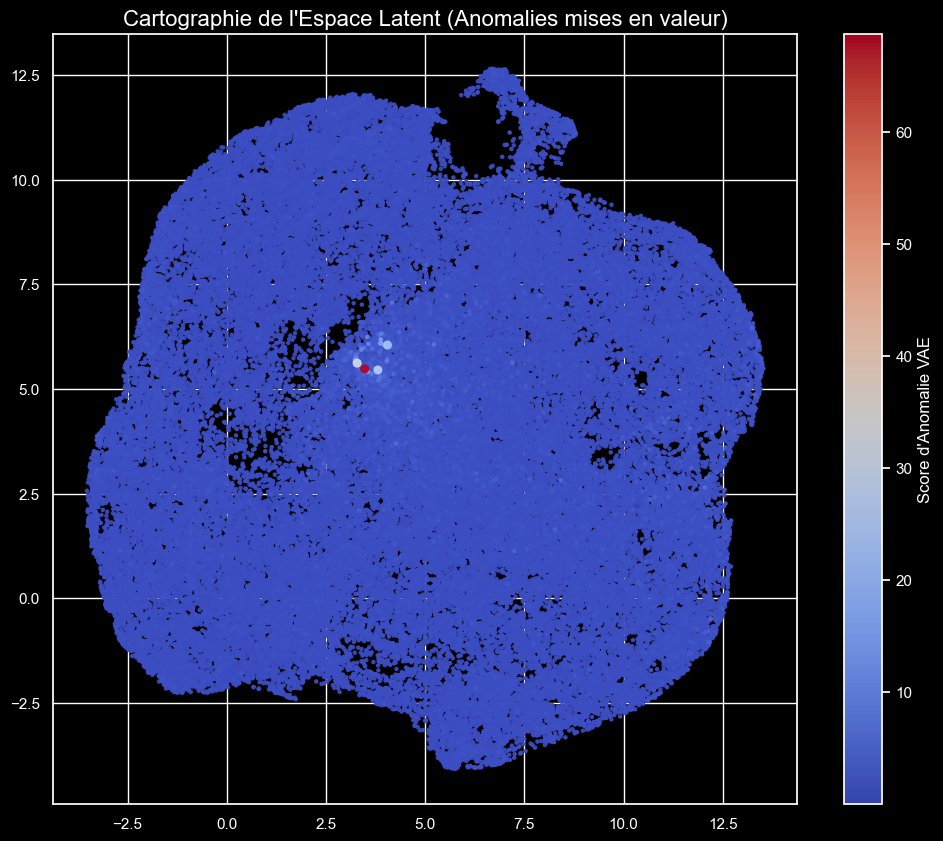

In [9]:
import numpy as np

# 1. On trie les index pour que les anomalies (scores élevés) soient à la fin du tableau
index_tries = np.argsort(df_results['anomaly_score'])

# 2. On réordonne nos points 2D et nos couleurs
latent_trie = latent_2d[index_tries]
scores_tries = df_results['anomaly_score'].iloc[index_tries]

# 3. On crée la taille des points (petit pour les normaux, plus gros pour les anomalies)
tailles = np.where(scores_tries > 20, 30, 5) 

plt.figure(figsize=(12, 10))
plt.style.use('dark_background')

scatter = plt.scatter(
    latent_trie[:, 0], 
    latent_trie[:, 1], 
    c=scores_tries, 
    cmap='coolwarm', 
    s=tailles, # Les anomalies seront 6 fois plus grosses
    alpha=0.9
)

plt.colorbar(scatter, label="Score d'Anomalie VAE")
plt.title("Cartographie de l'Espace Latent (Anomalies mises en valeur)", fontsize=16)
plt.show()

In [10]:
# 1. On sélectionne les 100 étoiles avec le plus gros score d'anomalie
top_100_anomalies = df_results.sort_values(by='anomaly_score', ascending=False).head(100)

# 2. On définit le nom du fichier
chemin_csv = "top_100_anomalies_gaia.csv"

# 3. Sauvegarde au format CSV (lisible par Excel, ou par d'autres scientifiques)
top_100_anomalies.to_csv(chemin_csv, index=False)

print(f"✅ Top 100 sauvegardé avec succès dans le fichier : {chemin_csv}")

✅ Top 100 sauvegardé avec succès dans le fichier : top_100_anomalies_gaia.csv


In [1]:
pwd

'C:\\Users\\mail-'